# Method 1 (Baseline) – Matrix Factorization with BPR Loss
## Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import random

## Data Preprocessing & Encoding
Neural networks need contiguous integers starting from 0 up to N-1. Since your original user IDs and book IDs (ISBNs/internal IDs) might be alphanumeric or non-contiguous, we must create mappings.

In [2]:
# Load interactions
interactions_path = Path.cwd().parent/"data"/"interactions_train.csv"
df = pd.read_csv(interactions_path)
df = df.rename(columns={"u": "user_id", "i": "item_id"})

# Creating mappings for Users and Items
user_ids = df["user_id"].unique()
item_ids = df["item_id"].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
idx2user = {i: u for i, u in enumerate(user_ids)}

item2idx = {i: idx for idx, i in enumerate(item_ids)}
idx2item = {idx: i for idx, i in enumerate(item_ids)}

num_users = len(user_ids)
num_items = len(item_ids)

# Mapping the dataframe to these new indices
df["user_idx"] = df["user_id"].map(user2idx)
df["item_idx"] = df["item_id"].map(item2idx)

# Creating a dictionary of all books read by each user (for negative sampling)
# Grouping by user_idx to get a set of positive item_idx
user_history = df.groupby("user_idx")["item_idx"].apply(set).to_dict()

### PyTorch Dataset with Negative Sampling
For every row in our dataset (which represents a user reading a book—a positive interaction), we need to randomly sample a book that the user has *not* read.

In [3]:
class BPRDataset(Dataset):
    def __init__(self, df, user_history, num_items):
        self.users = df['user_idx'].values
        self.pos_items = df['item_idx'].values
        self.user_history = user_history
        self.num_items = num_items

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user = self.users[idx]
        pos_item = self.pos_items[idx]
        
        # Negative Sampling: Randomly pick an item until it's NOT in user's history
        neg_item = random.randint(0, self.num_items - 1)
        while neg_item in self.user_history[user]:
            neg_item = random.randint(0, self.num_items - 1)
            
        return torch.tensor(user, dtype=torch.long), \
               torch.tensor(pos_item, dtype=torch.long), \
               torch.tensor(neg_item, dtype=torch.long)

# Initialize DataLoader
train_dataset = BPRDataset(df, user_history, num_items)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=0)  # put num_workers t=4 in the .py file (don't work well in a .ipynb file)

## PyTorch BPR Model
The architecture consists of standard embedding layers. Initialization is key here; small standard deviations help Matrix Factorization converge smoothly.

In [4]:
class MatrixFactorizationBPR(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=64):
        super(MatrixFactorizationBPR, self).__init__()
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        
        # Initialize embeddings with small random values
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, user, pos_item, neg_item):
        # Lookup embeddings
        u = self.user_emb(user)           # Shape: (batch_size, embed_dim)
        i_pos = self.item_emb(pos_item)   # Shape: (batch_size, embed_dim)
        i_neg = self.item_emb(neg_item)   # Shape: (batch_size, embed_dim)
        
        # Compute dot products (scores)
        pos_score = (u * i_pos).sum(dim=1)
        neg_score = (u * i_neg).sum(dim=1)
        
        return pos_score, neg_score
    
    def get_user_scores(self, user):
        # Used for inference to get all item scores for a specific user
        u = self.user_emb(user)
        # Dot product with ALL items
        scores = torch.matmul(u, self.item_emb.weight.T)
        return scores

### Training
The BPR loss function simply tries to maximize the margin between the positive score and the negative score using a Log-Sigmoid function.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = MatrixFactorizationBPR(num_users, num_items, embed_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5) # weight_decay acts as L2 regularization

epochs = 10

model.train()
for epoch in range(epochs):
    total_loss = 0
    for user, pos_item, neg_item in train_loader:
        user = user.to(device)
        pos_item = pos_item.to(device)
        neg_item = neg_item.to(device)
        
        optimizer.zero_grad()
        
        pos_score, neg_score = model(user, pos_item, neg_item)
        
        # BPR Loss: - mean(log(sigmoid(pos_score - neg_score)))
        loss = -torch.nn.functional.logsigmoid(pos_score - neg_score).mean()
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

cuda
Epoch 1/10 | Loss: 0.6676
Epoch 2/10 | Loss: 0.5379
Epoch 3/10 | Loss: 0.3940
Epoch 4/10 | Loss: 0.2982
Epoch 5/10 | Loss: 0.2411
Epoch 6/10 | Loss: 0.2083
Epoch 7/10 | Loss: 0.1897
Epoch 8/10 | Loss: 0.1785
Epoch 9/10 | Loss: 0.1704
Epoch 10/10 | Loss: 0.1648


## Generating the Submission (Top-10)

In [8]:
model.eval()
recommendations = []

with torch.no_grad():
    for user_idx in range(num_users):
        user_tensor = torch.tensor([user_idx]).to(device)
        
        # Get scores for all items
        scores = model.get_user_scores(user_tensor).squeeze()
        
        # Mask out items the user has already read by setting their score to -infinity
        read_items = list(user_history[user_idx])
        scores[read_items] = -float('inf')
        
        # Get indices of top 10 scores
        top_10_idx = torch.topk(scores, k=10).indices.cpu().numpy()
        
        # Map indices back to original IDs
        original_user_id = idx2user[user_idx]
        top_10_item_ids = [idx2item[idx] for idx in top_10_idx]
        
        # Append to results (Modify formatting based on your exact sample_submission.csv)
        recommendations.append({
            'user_id': original_user_id,
            'recommendation': " ".join([str(i) for i in top_10_item_ids]) 
        })

submission_df = pd.DataFrame(recommendations)
submission_df['user_id'] = pd.to_numeric(submission_df['user_id'])
submission_df = submission_df.sort_values(by='user_id').reset_index(drop=True)
submission_df.to_csv(Path.cwd().parent/"submissions"/'submission_pytorch_method1.csv', index=False)

## Data Augmentation & Preprocessing [not tested for now]
### Imports

In [ ]:
import requests
import time
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import pickle

### Fetching Metadata (Google Books API)

In [ ]:
# Load your items dataset
items_df = pd.read_csv(Path.cwd().parent/"data"/'items.csv')

# Create empty columns for our new data
items_df['description'] = ""
items_df['page_count'] = 0
items_df['published_year'] = ""

def fetch_google_books_metadata(isbn):
    """Fetches book metadata from Google Books API using ISBN."""
    if pd.isna(isbn) or str(isbn).strip() == "":
        return None, 0, None
    
    # Standardize ISBN format (remove dashes)
    isbn = str(isbn).replace('-', '').strip()
    url = f"https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn}"
    
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            data = response.json()
            if 'items' in data and len(data['items']) > 0:
                volume_info = data['items'][0].get('volumeInfo', {})
                
                description = volume_info.get('description', '')
                page_count = volume_info.get('pageCount', 0)
                published_date = volume_info.get('publishedDate', '')
                
                # Extract just the year if available
                year = published_date[:4] if published_date else ''
                
                return description, page_count, year
    except requests.exceptions.RequestException:
        pass # Handle timeouts or network errors silently for the loop
    
    return None, 0, None

# Iterate through the dataset and fetch data (wrapped in tqdm for a progress bar)
print("Fetching metadata from Google Books API...")
descriptions, page_counts, years = [], [], []

for isbn in tqdm(items_df['isbn']):
    desc, pages, year = fetch_google_books_metadata(isbn)
    descriptions.append(desc if desc else "")
    page_counts.append(pages if pages else 0)
    years.append(year if year else "")
    
    # Be polite to the API to avoid getting rate-limited
    time.sleep(0.1) 

# Assign the fetched data back to the dataframe
items_df['description'] = descriptions
items_df['page_count'] = page_counts
items_df['published_year'] = years

# Save the augmented dataset so you only have to do this once
items_df.to_csv('items_augmented.csv', index=False)
print("Augmented data saved to items_augmented.csv")

### Fetching Metadata (OpenLibrary API)

In [ ]:
# Load your items dataset
items_df = pd.read_csv(Path.cwd().parent/"data"/'items.csv')

# Create empty columns for our new data
items_df['description'] = ""
items_df['page_count'] = 0
items_df['published_year'] = ""

def fetch_openlibrary_metadata(isbn):
    """Fetches book metadata from OpenLibrary API using ISBN."""
    if pd.isna(isbn) or str(isbn).strip() == "":
        return None, 0, None
    
    # Standardize ISBN format (remove dashes)
    isbn = str(isbn).replace('-', '').strip()
    
    # OpenLibrary API endpoint using jscmd=data for a clean, aggregated summary
    url = f"https://openlibrary.org/api/books?bibkeys=ISBN:{isbn}&format=json&jscmd=data"
    
    # OpenLibrary asks developers to provide a User-Agent with contact info
    headers = {
        'User-Agent': 'UniversityLibraryRecommender/1.0 (mailto:julien.delez@epfl.ch)'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=5)
        if response.status_code == 200:
            data = response.json()
            book_key = f"ISBN:{isbn}"
            
            if book_key in data:
                book_data = data[book_key]
                
                # Extract page count
                page_count = book_data.get('number_of_pages', 0)
                
                # Extract year from publish date (e.g., "October 14, 2005" -> "2005")
                published_date = book_data.get('publish_date', '')
                year = ""
                if published_date:
                    match = re.search(r'\d{4}', published_date)
                    if match:
                        year = match.group(0)
                        
                # OpenLibrary often stores summaries/descriptions under 'notes' or 'excerpts' in this endpoint
                description = book_data.get('notes', '')
                if not description:
                    # Fallback: Check if they provided a URL to the full record
                    url_record = book_data.get('url', '')
                    description = f"See full record at: {url_record}" if url_record else ""
                
                return str(description), page_count, year
                
    except requests.exceptions.RequestException:
        pass # Handle timeouts or network errors silently to keep the loop going
    
    return None, 0, None

# Iterate through the dataset and fetch data
print("Fetching metadata from OpenLibrary API...")
descriptions, page_counts, years = [], [], []

for isbn in tqdm(items_df['isbn']):
    desc, pages, year = fetch_openlibrary_metadata(isbn)
    descriptions.append(desc if desc else "")
    page_counts.append(pages if pages else 0)
    years.append(year if year else "")
    
    # OpenLibrary is a non-profit, so rate-limiting yourself is good etiquette
    # A brief pause prevents overwhelming their servers
    time.sleep(0.1) 

# Assign the fetched data back to the dataframe
items_df['description'] = descriptions
items_df['page_count'] = page_counts
items_df['published_year'] = years

# Save the augmented dataset
items_df.to_csv('items_augmented.csv', index=False)
print("Augmented data saved to items_augmented.csv")

### Generating Text Embeddings

In [ ]:
# 1. Load the augmented dataset
items_df = pd.read_csv(Path.cwd().parent/"data"/'items_augmented.csv')

# Fill NaN values with empty strings to avoid errors during concatenation
cols_to_fill = ['Title', 'Author', 'Subjects', "Publisher", "description"]
items_df[cols_to_fill] = items_df[cols_to_fill].fillna("")

# 2. Concatenate relevant text fields into a single rich string per book
# Example: "Title: The Hobbit. Author: J.R.R. Tolkien. Topic: Fantasy. Description: Bilbo Baggins..."
items_df['combined_text'] = (
    "Title: " + items_df['Title'] + ". " +
    "Author: " + items_df['Author'] + ". " +
    "Topic: " + items_df['Subjects'] + ". " +
    "Description: " + items_df['description']
)

# 3. Load a pre-trained Sentence Transformer model
# 'all-MiniLM-L6-v2' is incredibly fast, lightweight, and maps text to a 384-dimensional vector.
# It will automatically use your RTX 2080 Ti / 4070 if CUDA is available.
print("Loading Sentence Transformer model")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# 4. Generate embeddings for all books
print(f"Generating embeddings for {len(items_df)} items on {device}")
text_list = items_df['combined_text'].tolist()

# The encode method automatically handles batching and tokenization
embeddings = model.encode(text_list, batch_size=128, show_progress_bar=True)

# 5. Create a mapping dictionary from your original item_id to its embedding
# This ensures you can easily look up the exact vector for any book later.
item_id_to_embedding = {}
for idx, item_id in enumerate(items_df['item_id']):
    item_id_to_embedding[item_id] = embeddings[idx]

# 6. Save the embeddings dictionary to disk using Pickle
output_file = 'item_text_embeddings.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(item_id_to_embedding, f)

print(f"Successfully saved text embeddings of shape {embeddings.shape} to {output_file}")

# Method 2 (Intermediate) – Two-Tower Neural Network (Content-Aware) 
## Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools
import random

## Feature Preprocessing & Tensor Creation
First, we need to load our augmented data and convert the metadata into numeric formats that our neural network can process.

### Loading the datasets

In [4]:
# Load datasets
interactions_path = Path.cwd().parent/"data"/"interactions_train.csv"
items_path = Path.cwd().parent/"data"/"items.csv"
interactions_df = pd.read_csv(interactions_path)
interactions_df = interactions_df.rename(columns={"u": "user_id", "i": "item_id", "t": "timestamp"})
items_df = pd.read_csv(items_path)
items_df = items_df.rename(columns={"i" : "item_id"})

### Temporal 80/20 Split

In [5]:
# Sort chronologically per user
interactions_df = interactions_df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# Calculate rank and total interactions
interactions_df['interaction_rank'] = interactions_df.groupby('user_id')['timestamp'].rank(method='first', ascending=True)
interactions_df['total_interactions'] = interactions_df.groupby('user_id')['timestamp'].transform('count')

# Split (Users with only 1 interaction default to train)
train_df = interactions_df[interactions_df['interaction_rank'] <= interactions_df['total_interactions'] * 0.8].copy()
val_df = interactions_df[interactions_df['interaction_rank'] > interactions_df['total_interactions'] * 0.8].copy()

### Encoding

In [8]:
# Fill missing metadata
items_df['Author'] = items_df['Author'].fillna('Unknown')
items_df['Publisher'] = items_df['Publisher'].fillna('Unknown')
items_df['Subjects'] = items_df['Subjects'].fillna('Unknown')

# Create index mappings (using ALL data so no IDs are unknown during inference)
user2idx = {u: i for i, u in enumerate(interactions_df['user_id'].unique())}
idx2user = {i: u for i, u in enumerate(interactions_df['user_id'].unique())}

item2idx = {i: idx for idx, i in enumerate(items_df['item_id'].unique())}
idx2item = {idx: i for idx, i in enumerate(items_df['item_id'].unique())}

author2idx = {a: i for i, a in enumerate(items_df['Author'].unique())}
publisher2idx = {p: i for i, p in enumerate(items_df['Publisher'].unique())}
topic2idx = {t: i for i, t in enumerate(items_df['Subjects'].unique())}

num_users = len(user2idx)
num_items = len(item2idx)

# Map Train and Val dataframes
train_df['user_idx'] = train_df['user_id'].map(user2idx)
train_df['item_idx'] = train_df['item_id'].map(item2idx)
val_df['user_idx'] = val_df['user_id'].map(user2idx)
val_df['item_idx'] = val_df['item_id'].map(item2idx)

### Fast Lookup Tensors & History

In [9]:
item_metadata_lookup = np.zeros((num_items, 3), dtype=np.int64)
for _, row in items_df.iterrows():
    if row['item_id'] in item2idx:
        i_idx = item2idx[row['item_id']]
        item_metadata_lookup[i_idx, 0] = author2idx[row['Author']]
        item_metadata_lookup[i_idx, 1] = publisher2idx[row['Publisher']]
        item_metadata_lookup[i_idx, 2] = topic2idx[row['Subjects']]

item_metadata_tensor = torch.tensor(item_metadata_lookup, dtype=torch.long)

# Dictionaries for masking and evaluation
train_user_history = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
val_user_history = val_df.groupby('user_idx')['item_idx'].apply(list).to_dict()

## Dataset and Architecture

In [10]:
class ExplicitBPRDataset(Dataset):
    def __init__(self, df, user_history, num_items):
        self.users = df['user_idx'].values
        self.pos_items = df['item_idx'].values
        self.user_history = user_history
        self.num_items = num_items

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user = self.users[idx]
        pos_item = self.pos_items[idx]
        
        # Explicit Negative Sampling: Randomly pick until it's not in user's history
        neg_item = random.randint(0, self.num_items - 1)
        # Using .get() with an empty set fallback in case a user somehow has no history
        while neg_item in self.user_history.get(user, set()):
            neg_item = random.randint(0, self.num_items - 1)
            
        return (
            torch.tensor(user, dtype=torch.long), 
            torch.tensor(pos_item, dtype=torch.long), 
            torch.tensor(neg_item, dtype=torch.long)
        )

class TwoTowerRecommender(nn.Module):
    def __init__(self, num_users, num_items, num_authors, num_publishers, num_topics, item_metadata, embed_dim=64):
        super(TwoTowerRecommender, self).__init__()
        self.register_buffer('item_metadata', item_metadata)
        
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        self.author_emb = nn.Embedding(num_authors, embed_dim // 2)
        self.publisher_emb = nn.Embedding(num_publishers, embed_dim // 2)
        self.topic_emb = nn.Embedding(num_topics, embed_dim // 2)
        
        self.item_bias = nn.Embedding(num_items, 1)
        nn.init.zeros_(self.item_bias.weight)
        
        concat_dim = embed_dim + (embed_dim // 2) * 3
        self.item_mlp = nn.Sequential(
            nn.Linear(concat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding) and m != self.item_bias:
                nn.init.normal_(m.weight, std=0.01)

    def get_item_representation(self, item_indices):
        i_emb = self.item_emb(item_indices)
        meta = self.item_metadata[item_indices]
        a_emb, p_emb, t_emb = self.author_emb(meta[:, 0]), self.publisher_emb(meta[:, 1]), self.topic_emb(meta[:, 2])
        concat_emb = torch.cat([i_emb, a_emb, p_emb, t_emb], dim=-1)
        return self.item_mlp(concat_emb)

    def forward(self, user, pos_item, neg_item):
        u_emb = self.user_emb(user)
        pos_i_emb = self.get_item_representation(pos_item)
        neg_i_emb = self.get_item_representation(neg_item)
        
        pos_score = (u_emb * pos_i_emb).sum(dim=1) + self.item_bias(pos_item).squeeze()
        neg_score = (u_emb * neg_i_emb).sum(dim=1) + self.item_bias(neg_item).squeeze()
        return pos_score, neg_score

## Evaluation & Plotting Tools
We evaluate actual Precision@10 on the validation set after every epoch.

In [11]:
def evaluate_precision_at_k(model, val_user_history, train_user_history, device, k=10):
    """Calculates Precision@K for the validation set."""
    model.eval()
    precisions = []
    
    with torch.no_grad():
        all_items = torch.arange(num_items, device=device)
        all_item_embs = model.get_item_representation(all_items)
        all_item_biases = model.item_bias(all_items).squeeze()
        
        for user_idx, true_items in val_user_history.items():
            u_tensor = torch.tensor([user_idx], device=device)
            u_emb = model.user_emb(u_tensor)
            
            # Predict scores for all items
            scores = torch.matmul(u_emb, all_item_embs.T).squeeze() + all_item_biases
            
            # Mask training items (we don't want to recommend books they already read in the past)
            past_items = list(train_user_history.get(user_idx, []))
            if past_items:
                scores[past_items] = -float('inf')
                
            top_k_items = torch.topk(scores, k=k).indices.cpu().numpy()
            
            # Calculate Precision
            hits = len(set(top_k_items).intersection(set(true_items)))
            precisions.append(hits / k)
            
    return np.mean(precisions)

def plot_learning_curves(train_losses, val_precisions, title="Training Profile"):
    """Plots Train Loss and Val Precision to visually find the elbow."""
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('BPR Train Loss', color=color)
    ax1.plot(train_losses, color=color, marker='o', label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Validation Precision@10', color=color)
    ax2.plot(val_precisions, color=color, marker='s', label='Val Precision@10')
    ax2.tick_params(axis='y', labelcolor=color)

    # Highlight the "Elbow" (Maximum Precision)
    best_epoch = np.argmax(val_precisions)
    ax2.axvline(x=best_epoch, color='grey', linestyle='--', alpha=0.7)
    ax2.text(best_epoch + 0.1, val_precisions[best_epoch], f'Best Epoch: {best_epoch+1}', color='black')

    fig.tight_layout()
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

## Hyperparameter Tuning Pipeline


Starting Grid Search for 8 combinations on cuda

--- Trial 1/8 | Params: {'embed_dim': 64, 'lr': 0.005, 'weight_decay': 0.0001} ---
  Epoch 01 | Train Loss: 0.6506 | Val P@10: 0.0010
  Epoch 02 | Train Loss: 0.5558 | Val P@10: 0.0016
  Epoch 03 | Train Loss: 0.4980 | Val P@10: 0.0017
  Epoch 04 | Train Loss: 0.4366 | Val P@10: 0.0018
  Epoch 05 | Train Loss: 0.3672 | Val P@10: 0.0021
  Epoch 06 | Train Loss: 0.3160 | Val P@10: 0.0022
  Epoch 07 | Train Loss: 0.2832 | Val P@10: 0.0024
  Epoch 08 | Train Loss: 0.2625 | Val P@10: 0.0027
  Epoch 09 | Train Loss: 0.2479 | Val P@10: 0.0027
  Epoch 10 | Train Loss: 0.2352 | Val P@10: 0.0024
  Epoch 11 | Train Loss: 0.2223 | Val P@10: 0.0026
  Epoch 12 | Train Loss: 0.2127 | Val P@10: 0.0025
  Epoch 13 | Train Loss: 0.2050 | Val P@10: 0.0025
  Epoch 14 | Train Loss: 0.2017 | Val P@10: 0.0028
  Epoch 15 | Train Loss: 0.1942 | Val P@10: 0.0026
  Epoch 16 | Train Loss: 0.1858 | Val P@10: 0.0026
  Epoch 17 | Train Loss: 0.1844 | Val P@10: 0.0026
 

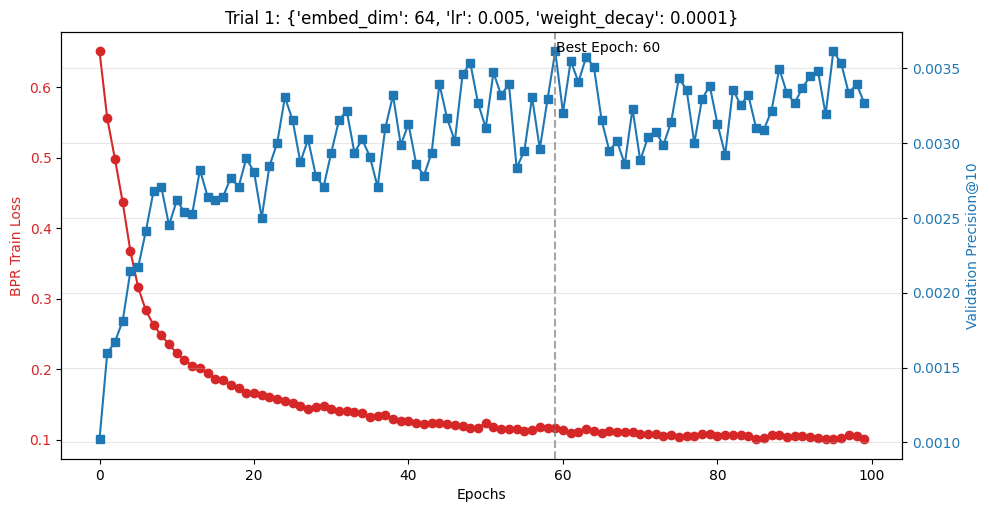

--- Trial 2/8 | Params: {'embed_dim': 64, 'lr': 0.005, 'weight_decay': 1e-05} ---
  Epoch 01 | Train Loss: 0.5852 | Val P@10: 0.0016
  Epoch 02 | Train Loss: 0.4004 | Val P@10: 0.0020
  Epoch 03 | Train Loss: 0.2960 | Val P@10: 0.0018
  Epoch 04 | Train Loss: 0.2386 | Val P@10: 0.0020
  Epoch 05 | Train Loss: 0.2077 | Val P@10: 0.0021
  Epoch 06 | Train Loss: 0.1833 | Val P@10: 0.0024
  Epoch 07 | Train Loss: 0.1639 | Val P@10: 0.0022
  Epoch 08 | Train Loss: 0.1572 | Val P@10: 0.0024
  Epoch 09 | Train Loss: 0.1413 | Val P@10: 0.0025
  Epoch 10 | Train Loss: 0.1294 | Val P@10: 0.0025
  Epoch 11 | Train Loss: 0.1239 | Val P@10: 0.0025
  Epoch 12 | Train Loss: 0.1104 | Val P@10: 0.0025
  Epoch 13 | Train Loss: 0.1139 | Val P@10: 0.0022
  Epoch 14 | Train Loss: 0.1038 | Val P@10: 0.0029
  Epoch 15 | Train Loss: 0.1007 | Val P@10: 0.0027
  Epoch 16 | Train Loss: 0.0933 | Val P@10: 0.0025
  Epoch 17 | Train Loss: 0.0911 | Val P@10: 0.0025
  Epoch 18 | Train Loss: 0.0845 | Val P@10: 0.0027


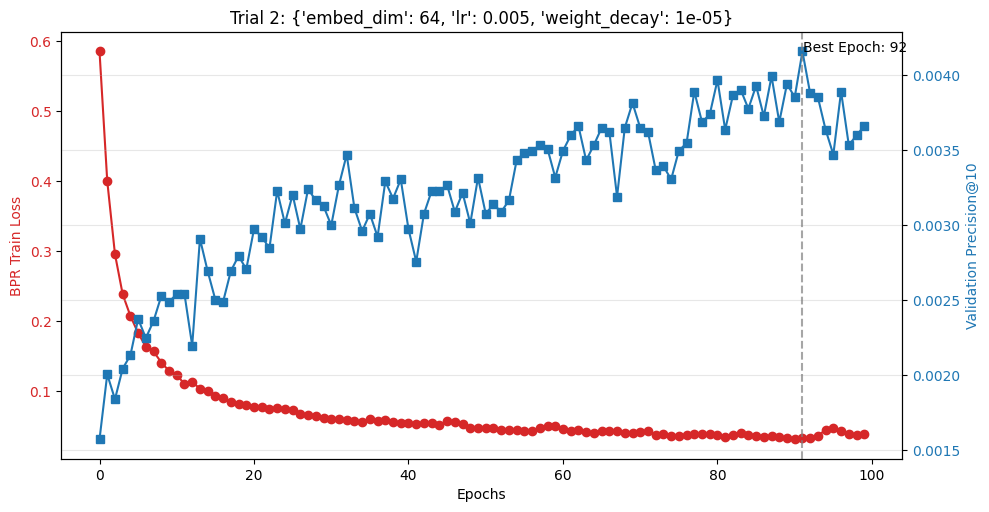

--- Trial 3/8 | Params: {'embed_dim': 64, 'lr': 0.001, 'weight_decay': 0.0001} ---
  Epoch 01 | Train Loss: 0.6913 | Val P@10: 0.0008
  Epoch 02 | Train Loss: 0.6046 | Val P@10: 0.0013
  Epoch 03 | Train Loss: 0.4881 | Val P@10: 0.0018
  Epoch 04 | Train Loss: 0.4361 | Val P@10: 0.0015
  Epoch 05 | Train Loss: 0.4142 | Val P@10: 0.0017
  Epoch 06 | Train Loss: 0.3999 | Val P@10: 0.0018
  Epoch 07 | Train Loss: 0.3897 | Val P@10: 0.0016
  Epoch 08 | Train Loss: 0.3850 | Val P@10: 0.0017
  Epoch 09 | Train Loss: 0.3832 | Val P@10: 0.0017
  Epoch 10 | Train Loss: 0.3750 | Val P@10: 0.0017
  Epoch 11 | Train Loss: 0.3700 | Val P@10: 0.0020
  Epoch 12 | Train Loss: 0.3609 | Val P@10: 0.0019
  Epoch 13 | Train Loss: 0.3510 | Val P@10: 0.0019
  Epoch 14 | Train Loss: 0.3315 | Val P@10: 0.0018
  Epoch 15 | Train Loss: 0.3119 | Val P@10: 0.0018
  Epoch 16 | Train Loss: 0.3013 | Val P@10: 0.0017
  Epoch 17 | Train Loss: 0.2905 | Val P@10: 0.0018
  Epoch 18 | Train Loss: 0.2802 | Val P@10: 0.0021

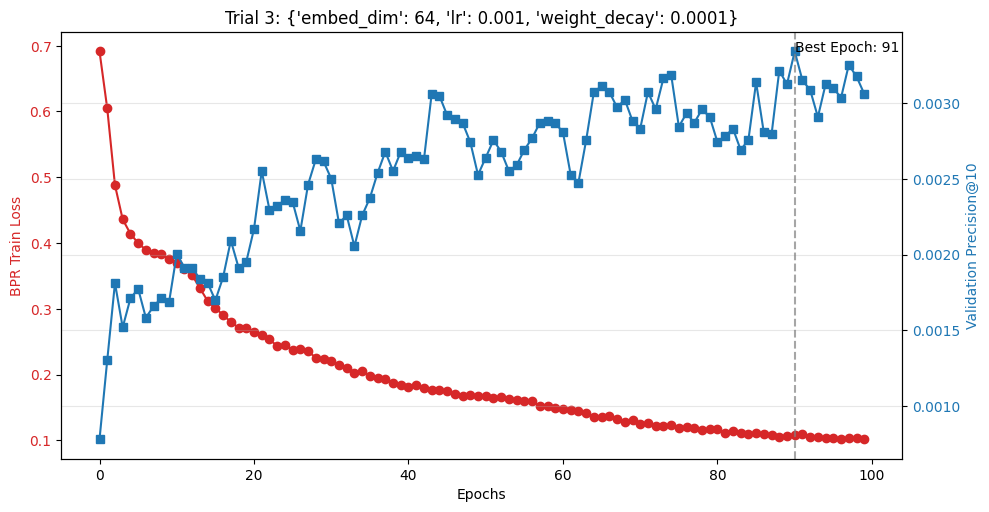

--- Trial 4/8 | Params: {'embed_dim': 64, 'lr': 0.001, 'weight_decay': 1e-05} ---
  Epoch 01 | Train Loss: 0.6791 | Val P@10: 0.0003
  Epoch 02 | Train Loss: 0.5237 | Val P@10: 0.0016
  Epoch 03 | Train Loss: 0.3994 | Val P@10: 0.0020
  Epoch 04 | Train Loss: 0.3395 | Val P@10: 0.0022
  Epoch 05 | Train Loss: 0.3157 | Val P@10: 0.0023
  Epoch 06 | Train Loss: 0.2872 | Val P@10: 0.0024
  Epoch 07 | Train Loss: 0.2740 | Val P@10: 0.0025
  Epoch 08 | Train Loss: 0.2657 | Val P@10: 0.0025
  Epoch 09 | Train Loss: 0.2539 | Val P@10: 0.0027
  Epoch 10 | Train Loss: 0.2389 | Val P@10: 0.0025
  Epoch 11 | Train Loss: 0.2275 | Val P@10: 0.0024
  Epoch 12 | Train Loss: 0.2121 | Val P@10: 0.0024
  Epoch 13 | Train Loss: 0.2007 | Val P@10: 0.0026
  Epoch 14 | Train Loss: 0.1930 | Val P@10: 0.0025
  Epoch 15 | Train Loss: 0.1837 | Val P@10: 0.0024
  Epoch 16 | Train Loss: 0.1801 | Val P@10: 0.0024
  Epoch 17 | Train Loss: 0.1697 | Val P@10: 0.0024
  Epoch 18 | Train Loss: 0.1641 | Val P@10: 0.0024


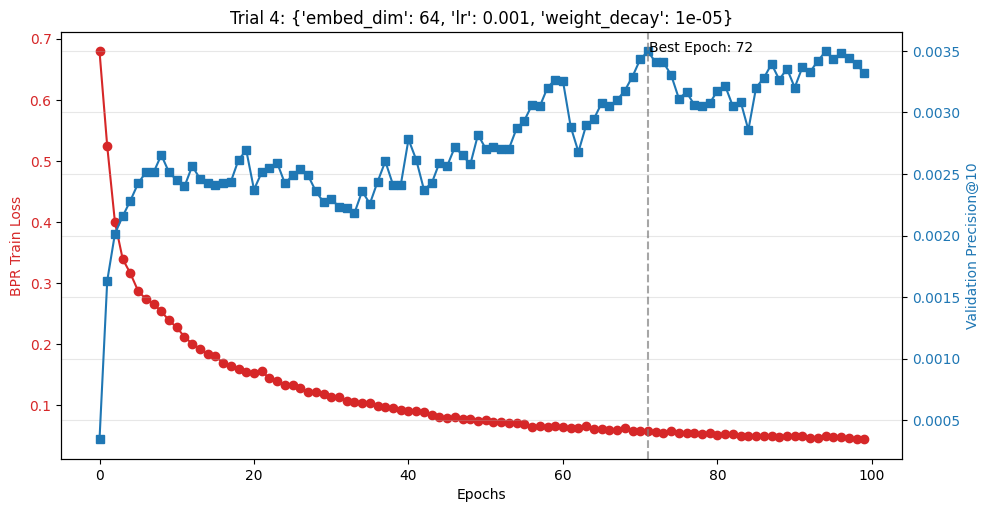

--- Trial 5/8 | Params: {'embed_dim': 128, 'lr': 0.005, 'weight_decay': 0.0001} ---
  Epoch 01 | Train Loss: 0.6477 | Val P@10: 0.0008
  Epoch 02 | Train Loss: 0.5250 | Val P@10: 0.0021
  Epoch 03 | Train Loss: 0.4124 | Val P@10: 0.0028
  Epoch 04 | Train Loss: 0.3497 | Val P@10: 0.0025
  Epoch 05 | Train Loss: 0.3144 | Val P@10: 0.0028
  Epoch 06 | Train Loss: 0.2859 | Val P@10: 0.0026
  Epoch 07 | Train Loss: 0.2640 | Val P@10: 0.0024
  Epoch 08 | Train Loss: 0.2513 | Val P@10: 0.0030
  Epoch 09 | Train Loss: 0.2302 | Val P@10: 0.0028
  Epoch 10 | Train Loss: 0.2169 | Val P@10: 0.0029
  Epoch 11 | Train Loss: 0.2084 | Val P@10: 0.0029
  Epoch 12 | Train Loss: 0.2004 | Val P@10: 0.0028
  Epoch 13 | Train Loss: 0.2000 | Val P@10: 0.0035
  Epoch 14 | Train Loss: 0.1860 | Val P@10: 0.0032
  Epoch 15 | Train Loss: 0.1802 | Val P@10: 0.0035
  Epoch 16 | Train Loss: 0.1712 | Val P@10: 0.0033
  Epoch 17 | Train Loss: 0.1703 | Val P@10: 0.0027
  Epoch 18 | Train Loss: 0.1649 | Val P@10: 0.003

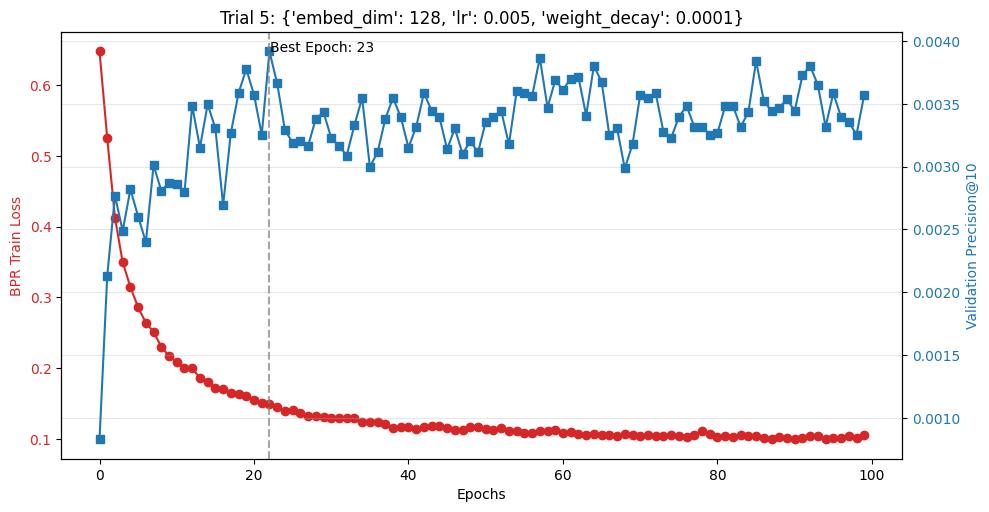

--- Trial 6/8 | Params: {'embed_dim': 128, 'lr': 0.005, 'weight_decay': 1e-05} ---
  Epoch 01 | Train Loss: 0.5788 | Val P@10: 0.0013
  Epoch 02 | Train Loss: 0.3971 | Val P@10: 0.0015
  Epoch 03 | Train Loss: 0.2997 | Val P@10: 0.0015
  Epoch 04 | Train Loss: 0.2445 | Val P@10: 0.0016
  Epoch 05 | Train Loss: 0.2037 | Val P@10: 0.0021
  Epoch 06 | Train Loss: 0.1760 | Val P@10: 0.0023
  Epoch 07 | Train Loss: 0.1522 | Val P@10: 0.0021
  Epoch 08 | Train Loss: 0.1376 | Val P@10: 0.0023
  Epoch 09 | Train Loss: 0.1279 | Val P@10: 0.0025
  Epoch 10 | Train Loss: 0.1304 | Val P@10: 0.0022
  Epoch 11 | Train Loss: 0.1102 | Val P@10: 0.0025
  Epoch 12 | Train Loss: 0.1017 | Val P@10: 0.0029
  Epoch 13 | Train Loss: 0.1010 | Val P@10: 0.0030
  Epoch 14 | Train Loss: 0.1055 | Val P@10: 0.0028
  Epoch 15 | Train Loss: 0.0920 | Val P@10: 0.0026
  Epoch 16 | Train Loss: 0.0841 | Val P@10: 0.0029
  Epoch 17 | Train Loss: 0.0817 | Val P@10: 0.0029
  Epoch 18 | Train Loss: 0.0772 | Val P@10: 0.0029

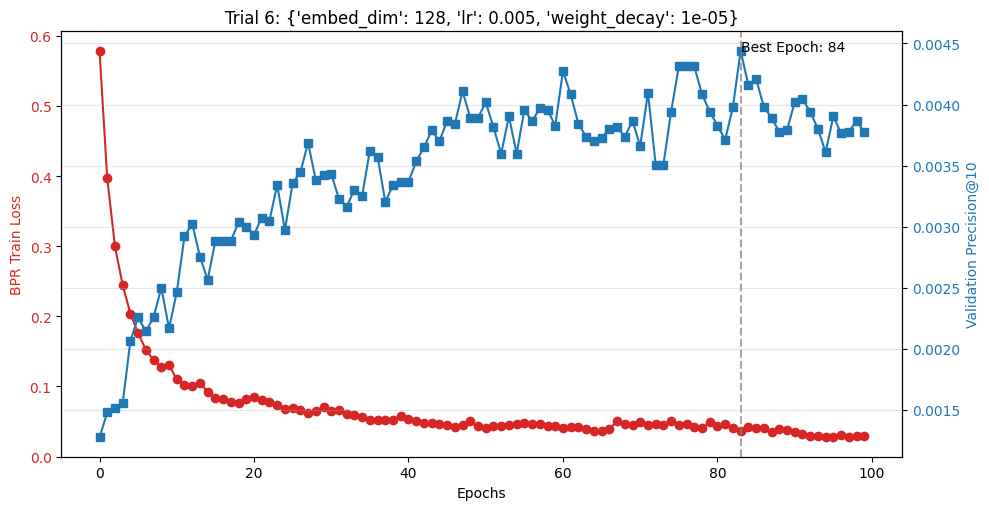

--- Trial 7/8 | Params: {'embed_dim': 128, 'lr': 0.001, 'weight_decay': 0.0001} ---
  Epoch 01 | Train Loss: 0.6865 | Val P@10: 0.0006
  Epoch 02 | Train Loss: 0.5816 | Val P@10: 0.0014
  Epoch 03 | Train Loss: 0.5058 | Val P@10: 0.0016
  Epoch 04 | Train Loss: 0.4746 | Val P@10: 0.0015
  Epoch 05 | Train Loss: 0.4611 | Val P@10: 0.0018
  Epoch 06 | Train Loss: 0.4480 | Val P@10: 0.0015
  Epoch 07 | Train Loss: 0.4275 | Val P@10: 0.0017
  Epoch 08 | Train Loss: 0.3897 | Val P@10: 0.0018
  Epoch 09 | Train Loss: 0.3546 | Val P@10: 0.0019
  Epoch 10 | Train Loss: 0.3316 | Val P@10: 0.0019
  Epoch 11 | Train Loss: 0.3099 | Val P@10: 0.0021
  Epoch 12 | Train Loss: 0.2973 | Val P@10: 0.0022
  Epoch 13 | Train Loss: 0.2851 | Val P@10: 0.0021
  Epoch 14 | Train Loss: 0.2742 | Val P@10: 0.0022
  Epoch 15 | Train Loss: 0.2590 | Val P@10: 0.0021
  Epoch 16 | Train Loss: 0.2496 | Val P@10: 0.0025
  Epoch 17 | Train Loss: 0.2330 | Val P@10: 0.0024
  Epoch 18 | Train Loss: 0.2244 | Val P@10: 0.002

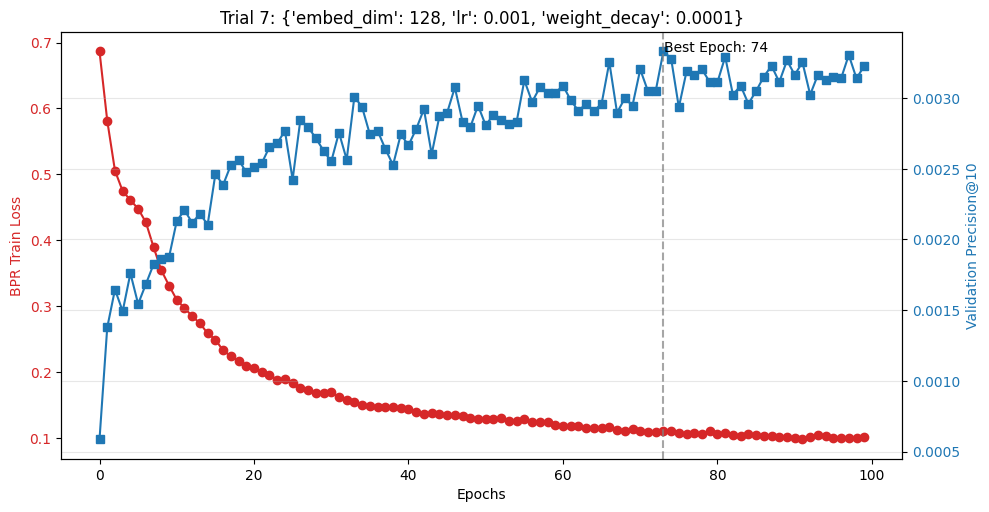

--- Trial 8/8 | Params: {'embed_dim': 128, 'lr': 0.001, 'weight_decay': 1e-05} ---
  Epoch 01 | Train Loss: 0.6594 | Val P@10: 0.0010
  Epoch 02 | Train Loss: 0.4555 | Val P@10: 0.0023
  Epoch 03 | Train Loss: 0.3651 | Val P@10: 0.0023
  Epoch 04 | Train Loss: 0.3182 | Val P@10: 0.0026
  Epoch 05 | Train Loss: 0.2881 | Val P@10: 0.0026
  Epoch 06 | Train Loss: 0.2605 | Val P@10: 0.0026
  Epoch 07 | Train Loss: 0.2331 | Val P@10: 0.0023
  Epoch 08 | Train Loss: 0.2227 | Val P@10: 0.0022
  Epoch 09 | Train Loss: 0.2100 | Val P@10: 0.0022
  Epoch 10 | Train Loss: 0.2015 | Val P@10: 0.0023
  Epoch 11 | Train Loss: 0.1948 | Val P@10: 0.0026
  Epoch 12 | Train Loss: 0.1916 | Val P@10: 0.0024
  Epoch 13 | Train Loss: 0.1797 | Val P@10: 0.0024
  Epoch 14 | Train Loss: 0.1735 | Val P@10: 0.0025
  Epoch 15 | Train Loss: 0.1647 | Val P@10: 0.0025
  Epoch 16 | Train Loss: 0.1674 | Val P@10: 0.0025
  Epoch 17 | Train Loss: 0.1570 | Val P@10: 0.0025
  Epoch 18 | Train Loss: 0.1539 | Val P@10: 0.0028

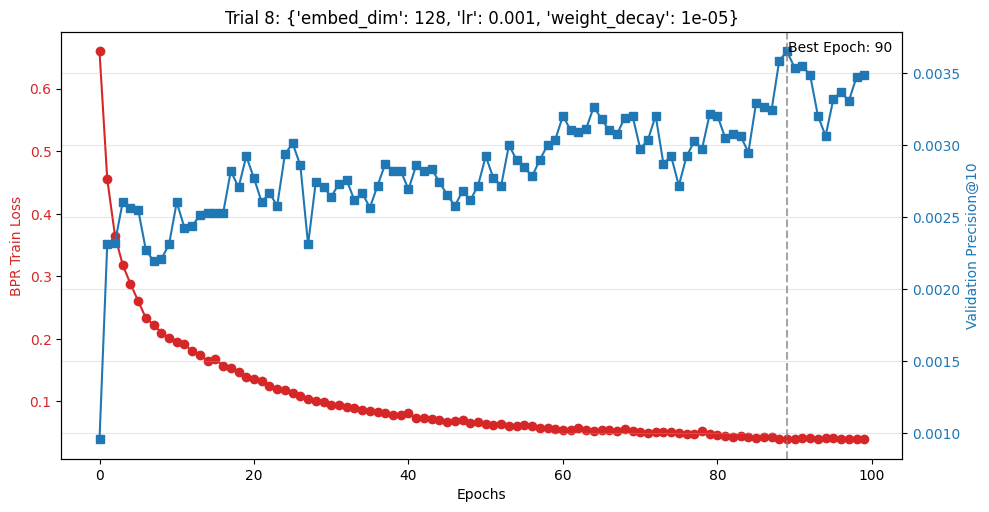


Grid Search Complete! Best Validation P@10: 0.0044
Best Hyperparameters: {'embed_dim': 128, 'lr': 0.005, 'weight_decay': 1e-05, 'optimal_epochs': 84}


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the new DataLoader with explicit negative sampling
train_dataset = ExplicitBPRDataset(train_df, train_user_history, num_items)
train_loader = DataLoader(
    train_dataset, 
    batch_size=1024, # You may need a slightly smaller batch size here compared to the fast version
    shuffle=True, 
    num_workers=0 # Keep at 0 for safe Windows local running with CPU loops
)

# Define Hyperparameter Grid
param_grid = {
    'embed_dim': [64, 128],
    'lr': [0.005, 0.001],
    'weight_decay': [1e-4, 1e-5]
}

keys, values = zip(*param_grid.items())
hyperparam_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_global_precision = 0
best_params = None
epochs_per_trial = 100 

print(f"Starting Grid Search for {len(hyperparam_combinations)} combinations on {device}\n")

for i, params in enumerate(hyperparam_combinations):
    print(f"--- Trial {i+1}/{len(hyperparam_combinations)} | Params: {params} ---")
    
    model = TwoTowerRecommender(
        num_users=num_users, num_items=num_items, 
        num_authors=len(author2idx), num_publishers=len(publisher2idx), num_topics=len(topic2idx),
        item_metadata=item_metadata_tensor, embed_dim=params['embed_dim']
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    
    train_losses = []
    val_precisions = []
    
    for epoch in range(epochs_per_trial):
        model.train()
        total_loss = 0
        
        # Unpack user, pos_item, AND neg_item directly from the loader
        for user, pos_item, neg_item in train_loader:
            user = user.to(device)
            pos_item = pos_item.to(device)
            neg_item = neg_item.to(device)
            
            optimizer.zero_grad()
            pos_score, neg_score = model(user, pos_item, neg_item)
            loss = -torch.nn.functional.logsigmoid(pos_score - neg_score).mean()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Validation Step
        val_prec = evaluate_precision_at_k(model, val_user_history, train_user_history, device, k=10)
        val_precisions.append(val_prec)
        
        print(f"  Epoch {epoch+1:02d} | Train Loss: {avg_loss:.4f} | Val P@10: {val_prec:.4f}")
    
    # Plotting and saving logic
    plot_learning_curves(train_losses, val_precisions, title=f"Trial {i+1}: {params}")
    
    max_prec = max(val_precisions)
    best_epoch_for_trial = val_precisions.index(max_prec) + 1
    
    if max_prec > best_global_precision:
        best_global_precision = max_prec
        best_params = params
        best_params['optimal_epochs'] = best_epoch_for_trial
        torch.save(model.state_dict(), 'best_twotower_model.pth')

print("\n" + "="*50)
print(f"Grid Search Complete! Best Validation P@10: {best_global_precision:.4f}")
print(f"Best Hyperparameters: {best_params}")
print("="*50)

## Loading the Best Model


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize the model using the optimal embed_dim found during your grid search.
# If you are still in the same notebook session, you can use best_params['embed_dim'].
# If you restarted your kernel, replace best_params['embed_dim'] with the actual integer (e.g., 128).
optimal_embed_dim = best_params['embed_dim'] 

best_model = TwoTowerRecommender(
    num_users=num_users, 
    num_items=num_items, 
    num_authors=len(author2idx), 
    num_publishers=len(publisher2idx), 
    num_topics=len(topic2idx),
    item_metadata=item_metadata_tensor, 
    embed_dim=optimal_embed_dim
).to(device)

# Load the saved state dictionary
best_model.load_state_dict(torch.load('best_twotower_model.pth', map_location=device))
best_model.eval()

print("Best model successfully loaded and ready for inference!")

Best model successfully loaded and ready for inference!


## Generate the Sorted Submission

In [17]:
# Create a mask of the ENTIRE user history (train + val) 
# so we don't recommend anything they've already read.
full_user_history = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()

recommendations = []

with torch.no_grad():
    print("Pre-computing item representations")
    # Pre-compute all item vectors and biases to massively speed up the user loop
    all_items = torch.arange(num_items, device=device)
    all_item_embs = best_model.get_item_representation(all_items)
    all_item_biases = best_model.item_bias(all_items).squeeze()
    
    print("Generating Top-10 predictions for all users")
    for user_idx in range(num_users):
        u_tensor = torch.tensor([user_idx], device=device)
        u_emb = best_model.user_emb(u_tensor)
        
        # Calculate scores: Dot product + Item Bias
        scores = torch.matmul(u_emb, all_item_embs.T).squeeze() + all_item_biases
        
        # Mask out all previously read items by setting their score to negative infinity
        read_items = list(full_user_history.get(user_idx, set()))
        if read_items:
            scores[read_items] = -float('inf')
            
        # Extract the indices of the top 10 highest scores
        top_10_idx = torch.topk(scores, k=10).indices.cpu().numpy()
        
        # Map internal indices back to the original Kaggle IDs
        original_user_id = idx2user[user_idx]
        top_10_item_ids = [idx2item[idx] for idx in top_10_idx]
        
        # Format for submission (space-separated string)
        recommendations.append({
            'user_id': original_user_id,
            'recommendation': " ".join([str(i) for i in top_10_item_ids]) 
        })

# Create DataFrame
submission_df = pd.DataFrame(recommendations)

# --- STRICT KAGGLE FORMATTING ---
# Force user_id to be numeric so it sorts mathematically (1, 2, 3... 10, 11) 
# rather than alphabetically (1, 10, 11... 2, 3)
submission_df['user_id'] = pd.to_numeric(submission_df['user_id'])
submission_df = submission_df.sort_values(by='user_id').reset_index(drop=True)

# Save to CSV
output_filename = Path.cwd().parent/"submissions"/'submission_pytorch_method2.csv'
submission_df.to_csv(output_filename, index=False)

Pre-computing item representations
Generating Top-10 predictions for all users


# Method 3 (Advanced) – Self-Attentive Sequential Recommendation (SASRec)
## Imports

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

## Sequential Data Preparation

In [ ]:
Sequential Data Preparation